# Stage 5: Model Training, Evaluation & Reporting

Trains Random Forest, Logistic Regression, and XGBoost classifiers on the
engineered features, evaluates them (cross-validation, ROC/confusion
matrices, fairness/bias audit, data-drift notes), and produces the final
policy-facing outputs (top-20 risk counties, choropleth, interpretable
decision tree).

**Requires:** `processed/df_labeled.csv`, `processed/X.csv`, `processed/y.csv`,
`processed/X_train.csv`, `processed/X_test.csv`, `processed/y_train.csv`,
`processed/y_test.csv`
**Produces:** `top20_risk_counties.png`, `pmos_predictions_all_counties.csv`

In [1]:
# IMPORT LIBRARIES
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from google.colab import drive
from sklearn.model_selection import (
    StratifiedKFold, cross_validate, cross_val_predict, RandomizedSearchCV
)
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import (
    classification_report, ConfusionMatrixDisplay, RocCurveDisplay, roc_curve,
    accuracy_score, f1_score, roc_auc_score, recall_score, precision_score,
    precision_recall_curve, fbeta_score, make_scorer
)

print("✅ SUCCESS: All libraries imported")

✅ SUCCESS: All libraries imported


In [2]:
# INSTALL XGBOOST - not pre-installed in Colab, run once per session
!pip install --quiet xgboost

In [3]:
# MOUNT DRIVE AND LOAD FEATURE-ENGINEERED ARTIFACTS

drive.mount("/content/drive")

FOLDER_NAME = "data"
DATASET_PATH = f"/content/drive/MyDrive/{FOLDER_NAME}"
PROCESSED_DIR = f"{DATASET_PATH}/processed"

df = pd.read_csv(f"{PROCESSED_DIR}/df_labeled.csv", dtype={"FIPS": str})
X = pd.read_csv(f"{PROCESSED_DIR}/X.csv")
y = pd.read_csv(f"{PROCESSED_DIR}/y.csv")["UNDERDIAGNOSIS_RISK"]
X_train = pd.read_csv(f"{PROCESSED_DIR}/X_train.csv")
X_test = pd.read_csv(f"{PROCESSED_DIR}/X_test.csv")
y_train = pd.read_csv(f"{PROCESSED_DIR}/y_train.csv")["UNDERDIAGNOSIS_RISK"]
y_test = pd.read_csv(f"{PROCESSED_DIR}/y_test.csv")["UNDERDIAGNOSIS_RISK"]

print(f"✅ SUCCESS: loaded engineered features ({X.shape[1]} features, "
      f"{len(X_train)} train / {len(X_test)} test rows)")

Mounted at /content/drive
✅ SUCCESS: loaded engineered features (20 features, 2515 train / 629 test rows)


In [4]:
# TRAIN ALL THREE MODELS
# Random Forest (primary) - predicts based on majority decision across all trees
# and gives feature importance scores/weights
# Logistic Regression (baseline) - linear boundary betw classes using scaled features
# can also compare to Silva and Ramphul regression models
# XGBoost (benchmark) - confirm random forest findings
# Use k-fold cross validation?

=== Random Forest ===
              precision    recall  f1-score   support

    Low Risk       0.93      0.95      0.94       495
   High Risk       0.81      0.72      0.76       134

    accuracy                           0.90       629
   macro avg       0.87      0.83      0.85       629
weighted avg       0.90      0.90      0.90       629



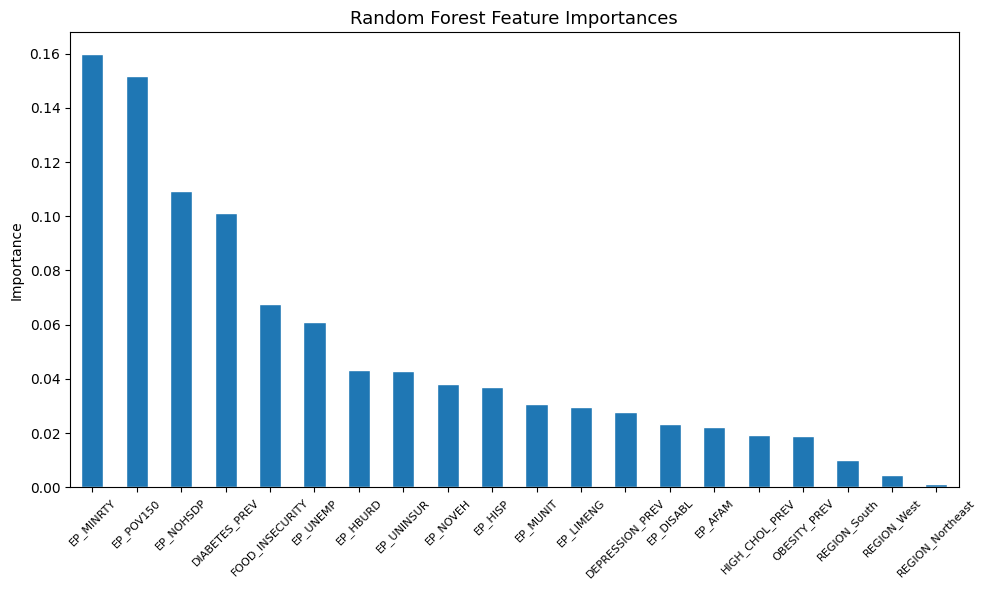


Top 10 features:
EP_MINRTY          0.159839
EP_POV150          0.151822
EP_NOHSDP          0.109271
DIABETES_PREV      0.101363
FOOD_INSECURITY    0.067534
EP_UNEMP           0.061035
EP_HBURD           0.043121
EP_UNINSUR         0.042889
EP_NOVEH           0.038198
EP_HISP            0.036992
dtype: float64


In [5]:
# Train Random Forest


rf = RandomForestClassifier(n_estimators=100, class_weight="balanced", random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("=== Random Forest ===")
print(classification_report(y_test, y_pred_rf, target_names=["Low Risk", "High Risk"]))

# Feature importance plot
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(10, 6))
importances.plot(kind="bar", ax=ax, edgecolor="white")
ax.set_title("Random Forest Feature Importances", fontsize=13)
ax.set_ylabel("Importance")
ax.tick_params(axis="x", rotation=45, labelsize=8)
plt.tight_layout()
plt.show()
print("\nTop 10 features:")
print(importances.head(10))

In [6]:
# Overfitting Check for Random Forest
print("=== Random Forest — Train ===")
print(classification_report(y_train, rf.predict(X_train), target_names=["Low Risk", "High Risk"]))

print("=== Random Forest — Test ===")
print(classification_report(y_test, rf.predict(X_test), target_names=["Low Risk", "High Risk"]))

=== Random Forest — Train ===
              precision    recall  f1-score   support

    Low Risk       1.00      1.00      1.00      1978
   High Risk       1.00      1.00      1.00       537

    accuracy                           1.00      2515
   macro avg       1.00      1.00      1.00      2515
weighted avg       1.00      1.00      1.00      2515

=== Random Forest — Test ===
              precision    recall  f1-score   support

    Low Risk       0.93      0.95      0.94       495
   High Risk       0.81      0.72      0.76       134

    accuracy                           0.90       629
   macro avg       0.87      0.83      0.85       629
weighted avg       0.90      0.90      0.90       629



In [7]:
# New Random Forest Model
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
f2_scorer = make_scorer(fbeta_score, beta=2)

param_dist = {
    "max_depth": [4, 6, 8, 10, None],  # limits the depth of the random forest tree
    "min_samples_leaf": [1, 3, 5, 10], # limits the min counties in the tree's leaf
    "min_samples_split": [2, 5, 10, 20],
    "max_features": ["sqrt", "log2", 0.5],
    "n_estimators": [100, 200, 300], # how many tress to build
}

# picks 30 random combinations using the param_dist & trains 5 separate models and avg scores
new_rf = RandomizedSearchCV(
    RandomForestClassifier(class_weight="balanced", random_state=42),
    param_distributions=param_dist,
    n_iter=30,
    scoring=f2_scorer,
    cv=cv,
    random_state=42,
    n_jobs=-1
)
new_rf.fit(X_train, y_train)
print(new_rf.best_params_)

{'n_estimators': 200, 'min_samples_split': 20, 'min_samples_leaf': 5, 'max_features': 0.5, 'max_depth': None}


In [8]:
# New Random Forest Model Result
print("=== Random Forest — Train ===")
print(classification_report(y_train, new_rf.predict(X_train), target_names=["Low Risk", "High Risk"]))

print("=== Random Forest — Test ===")
print(classification_report(y_test, new_rf.predict(X_test), target_names=["Low Risk", "High Risk"]))

=== Random Forest — Train ===
              precision    recall  f1-score   support

    Low Risk       0.99      0.95      0.97      1978
   High Risk       0.83      0.98      0.90       537

    accuracy                           0.95      2515
   macro avg       0.91      0.96      0.93      2515
weighted avg       0.96      0.95      0.95      2515

=== Random Forest — Test ===
              precision    recall  f1-score   support

    Low Risk       0.96      0.91      0.93       495
   High Risk       0.71      0.85      0.78       134

    accuracy                           0.90       629
   macro avg       0.83      0.88      0.85       629
weighted avg       0.91      0.90      0.90       629



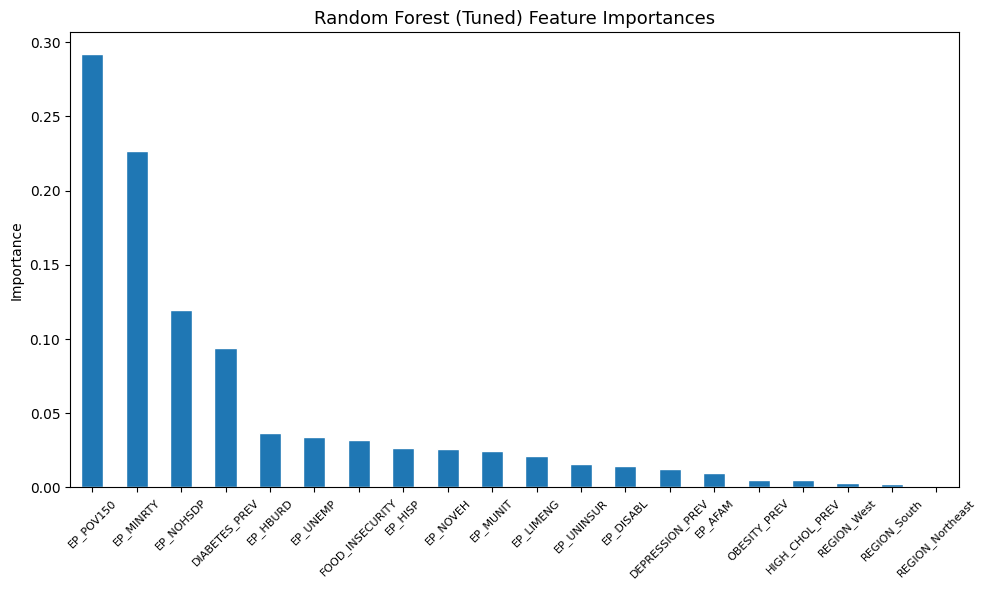


Top 10 features:
EP_POV150          0.292129
EP_MINRTY          0.226646
EP_NOHSDP          0.119374
DIABETES_PREV      0.093901
EP_HBURD           0.036839
EP_UNEMP           0.033720
FOOD_INSECURITY    0.031797
EP_HISP            0.026195
EP_NOVEH           0.025860
EP_MUNIT           0.024610
dtype: float64


In [9]:
# New Random Forest Feature importance plot
importances = pd.Series(new_rf.best_estimator_.feature_importances_, index=X.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
importances.plot(kind="bar", ax=ax, edgecolor="white")
ax.set_title("Random Forest (Tuned) Feature Importances", fontsize=13)
ax.set_ylabel("Importance")
ax.tick_params(axis="x", rotation=45, labelsize=8)
plt.tight_layout()
plt.show()

print("\nTop 10 features:")
print(importances.head(10))

In [10]:
# Train Logistic Regression on Top 10 Features

top10 = importances.head(10).index.tolist()
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train[top10])
X_test_scaled  = scaler.transform(X_test[top10])

lr = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

print("=== Logistic Regression (top 10 features) ===")
print(classification_report(y_test, y_pred_lr, target_names=["Low Risk", "High Risk"]))

=== Logistic Regression (top 10 features) ===
              precision    recall  f1-score   support

    Low Risk       0.96      0.87      0.91       495
   High Risk       0.65      0.86      0.74       134

    accuracy                           0.87       629
   macro avg       0.80      0.87      0.83       629
weighted avg       0.89      0.87      0.88       629



In [11]:
# Overfitting Check for Logistic Regression
print("=== Logistic Regression — Train ===")
print(classification_report(y_train, lr.predict(X_train_scaled), target_names=["Low Risk", "High Risk"]))

print("=== Logistic Regression — Test ===")
print(classification_report(y_test, lr.predict(X_test_scaled), target_names=["Low Risk", "High Risk"]))

=== Logistic Regression — Train ===
              precision    recall  f1-score   support

    Low Risk       0.96      0.88      0.92      1978
   High Risk       0.66      0.88      0.75       537

    accuracy                           0.88      2515
   macro avg       0.81      0.88      0.83      2515
weighted avg       0.90      0.88      0.88      2515

=== Logistic Regression — Test ===
              precision    recall  f1-score   support

    Low Risk       0.96      0.87      0.91       495
   High Risk       0.65      0.86      0.74       134

    accuracy                           0.87       629
   macro avg       0.80      0.87      0.83       629
weighted avg       0.89      0.87      0.88       629



In [12]:
# Train XGBoost


spw = (y_train == 0).sum() / (y_train == 1).sum()

xgb = XGBClassifier(scale_pos_weight=spw, random_state=42)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

print("=== XGBoost ===")
print(classification_report(y_test, y_pred_xgb, target_names=["Low Risk", "High Risk"]))

=== XGBoost ===
              precision    recall  f1-score   support

    Low Risk       0.95      0.94      0.95       495
   High Risk       0.79      0.81      0.80       134

    accuracy                           0.91       629
   macro avg       0.87      0.87      0.87       629
weighted avg       0.91      0.91      0.91       629



In [13]:
# Overfitting check for XGBoost
print("=== XGBoost (old) — Train ===")
print(classification_report(y_train, xgb.predict(X_train), target_names=["Low Risk", "High Risk"]))

print("=== XGBoost (old) — Test ===")
print(classification_report(y_test, xgb.predict(X_test), target_names=["Low Risk", "High Risk"]))

=== XGBoost (old) — Train ===
              precision    recall  f1-score   support

    Low Risk       1.00      1.00      1.00      1978
   High Risk       1.00      1.00      1.00       537

    accuracy                           1.00      2515
   macro avg       1.00      1.00      1.00      2515
weighted avg       1.00      1.00      1.00      2515

=== XGBoost (old) — Test ===
              precision    recall  f1-score   support

    Low Risk       0.95      0.94      0.95       495
   High Risk       0.79      0.81      0.80       134

    accuracy                           0.91       629
   macro avg       0.87      0.87      0.87       629
weighted avg       0.91      0.91      0.91       629



In [14]:
# 5 cross fold for RF and XGboost with tuning
def cv_recall_at_tuned_threshold(model, X, y, outer_cv, inner_cv):
    recalls, precisions, thresholds_used = [], [], []

    for train_idx, test_idx in outer_cv.split(X, y):
        X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
        y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]

        # INNER step: get honest out-of-fold probabilities on the training portion only
        inner_probs = cross_val_predict(model, X_tr, y_tr, cv=inner_cv, method="predict_proba")[:, 1]
        prec, rec, thresh = precision_recall_curve(y_tr, inner_probs)
        f2 = (5 * prec * rec) / (4 * prec + rec + 1e-10)
        best_thresh = thresh[np.argmax(f2)]
        thresholds_used.append(best_thresh)

        # fit on the FULL training fold, then evaluate on the held-out outer fold
        model.fit(X_tr, y_tr)
        probs_te = model.predict_proba(X_te)[:, 1]
        y_pred = (probs_te >= best_thresh).astype(int)

        recalls.append(recall_score(y_te, y_pred))
        precisions.append(precision_score(y_te, y_pred))

    print(f"Thresholds per fold: {[f'{t:.3f}' for t in thresholds_used]}")
    print(f"Recall: {np.mean(recalls):.3f} ± {np.std(recalls):.3f}")
    print(f"Precision: {np.mean(precisions):.3f} ± {np.std(precisions):.3f}")

outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("=== Random Forest ===")
cv_recall_at_tuned_threshold(rf, X, y, outer_cv, inner_cv)

print("=== XGBoost ===")
cv_recall_at_tuned_threshold(xgb, X, y, outer_cv, inner_cv)

=== Random Forest ===
Thresholds per fold: ['0.190', '0.270', '0.180', '0.210', '0.290']
Recall: 0.927 ± 0.038
Precision: 0.664 ± 0.034
=== XGBoost ===
Thresholds per fold: ['0.051', '0.032', '0.038', '0.016', '0.069']
Recall: 0.940 ± 0.022
Precision: 0.662 ± 0.025


In [15]:
# MODEL VALIDATION: 5-FOLD CROSS_VALIDATION
# Single 80/20 split eval = results may vary based on counties
# included in test set
# K-fold rotates the test set across 5 folds so all counties evaluated
# Outputs mean +- std - low std signals stable model, not chance


# StratifiedKFold - each fold should maintains same positive rate
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Mapping model names to model objects
# LR reqs scaling inside CV loop to prevent data leakage
# Pipeline ensures scaler is fit only on training folds, not test fold
models_cv = {
    "Random Forest": RandomForestClassifier(
        n_estimators=100, class_weight="balanced", random_state=42),
    "Logistic Regression": Pipeline([("scaler", StandardScaler()),
     ("lr", LogisticRegression(
         class_weight="balanced", max_iter=1000, random_state=42))]),
    "XGBoost": XGBClassifier(
        scale_pos_weight=(y==0).sum()/(y==1).sum(),
        random_state=42, verbosity=0, eval_metric="logloss")
}

cv_results = {}
print("Running 5-fold cross-validation across all 3,144 counties...\n")

for name, model in models_cv.items():
  scores = cross_validate(
      model, X, y, cv=skf,
      scoring=["accuracy", "f1", "roc_auc"],
      return_train_score=False
  )
  cv_results[name] = {
      "Accuracy": f"{scores['test_accuracy'].mean():.3f} ± {scores['test_accuracy'].std():.3f}",
      "F1 Score": f"{scores['test_f1'].mean():.3f} ± {scores['test_f1'].std():.3f}",
      "ROC-AUC": f"{scores['test_roc_auc'].mean():.3f} ± {scores['test_roc_auc'].std():.3f}",
  }
  print(f"✅ SUCCESS: {name} done")

print("\n=== 5-FOLD CROSS-VALIDATION RESULTS ===")
print("Mean ± Standard Deviation across 5 folds (lower std = more stable model)")
print(pd.DataFrame(cv_results).T.to_string())

Running 5-fold cross-validation across all 3,144 counties...

✅ SUCCESS: Random Forest done
✅ SUCCESS: Logistic Regression done
✅ SUCCESS: XGBoost done

=== 5-FOLD CROSS-VALIDATION RESULTS ===
Mean ± Standard Deviation across 5 folds (lower std = more stable model)
                          Accuracy       F1 Score        ROC-AUC
Random Forest        0.912 ± 0.012  0.779 ± 0.034  0.967 ± 0.006
Logistic Regression  0.880 ± 0.011  0.761 ± 0.018  0.952 ± 0.009
XGBoost              0.919 ± 0.007  0.814 ± 0.015  0.971 ± 0.002


In [16]:
# MODEL COMPARISON SUMMARY
# Accuracy: overall correct predictions
# F1 (high-risk): mean of precision + recall for high-risk class
# ROC-AUC: 0.5 = random chance, 1.0 = perfect separation

summary = pd.DataFrame({
    "Model": ["Random Forest","Logistic Regression", "XGBoost"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_xgb)
    ],
    "F1 (High-Risk)": [
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_xgb),
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, rf.predict_proba(X_test)[:,1]),
        roc_auc_score(y_test, lr.predict_proba(X_test_scaled)[:,1]),
        roc_auc_score(y_test, xgb.predict_proba(X_test)[:,1]),
    ]
})

print("=== MODEL COMPARISON SUMMARY ===\n")
print(summary.round(3).to_string(index=False))

=== MODEL COMPARISON SUMMARY ===

              Model  Accuracy  F1 (High-Risk)  ROC-AUC
      Random Forest     0.903           0.759    0.996
Logistic Regression     0.871           0.740    0.937
            XGBoost     0.914           0.800    0.997


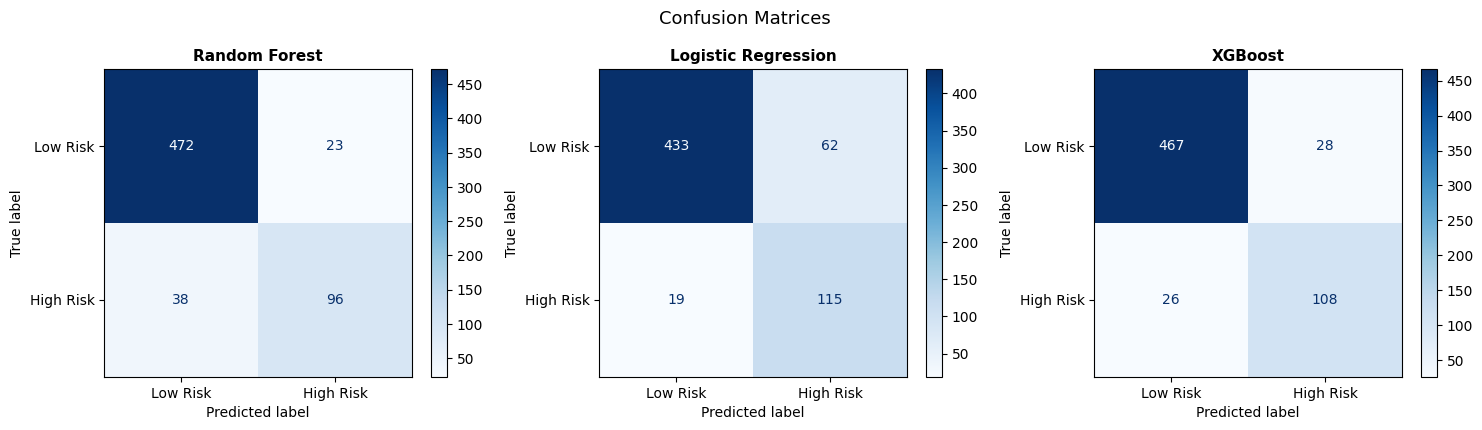

In [17]:
# Confusion Matrices

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, y_pred) in zip(axes, [
    ("Random Forest",       y_pred_rf),
    ("Logistic Regression", y_pred_lr),
    ("XGBoost",             y_pred_xgb),
]):
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred,
        display_labels=["Low Risk", "High Risk"],
        cmap="Blues", ax=ax
    )
    ax.set_title(name, fontsize=11, fontweight="bold")
plt.suptitle("Confusion Matrices", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

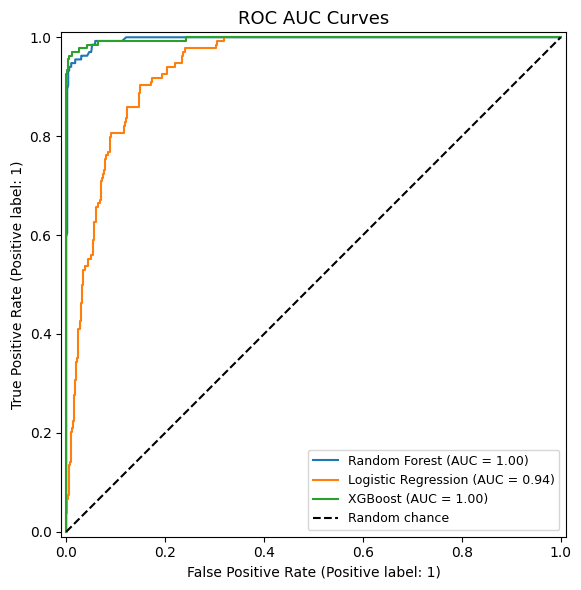

In [18]:
# ROC AUC Curves

fig, ax = plt.subplots(figsize=(7, 6))
for name, y_prob in [
    ("Random Forest",       rf.predict_proba(X_test)[:, 1]),
    ("Logistic Regression", lr.predict_proba(X_test_scaled)[:, 1]),
    ("XGBoost",             xgb.predict_proba(X_test)[:, 1]),
]:
    RocCurveDisplay.from_predictions(y_test, y_prob, name=name, ax=ax)
ax.plot([0, 1], [0, 1], "k--", label="Random chance")
ax.set_title("ROC AUC Curves", fontsize=13)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

In [19]:
# SYSTEMIC BIAS AUDIT
# Checks whether model systematically misses high-risk counties in
# ones with high minority/Black/poverty populations
# Higher False Negative Rate (FNR) = structural bias/inequity

# Attach demographic context/predictions to test set
test_idx = X_test.index
bias_df = df.loc[test_idx,["COUNTY", "ST_ABBR", "EP_AFAM", "EP_MINRTY",
                            "EP_POV150"]].copy()
bias_df["TRUE_LABEL"] = y_test.values
bias_df["RF_PREDICTION"] = y_pred_rf
bias_df["RF_PROB"] = rf.predict_proba(X_test)[:,1]

# Split counties into high/low groups by national median
for col, label in [("EP_MINRTY", "HIGH_MINORITY"),
                   ("EP_AFAM", "HIGH_BLACK"),
                   ("EP_POV150", "HIGH_POVERTY")]:
    bias_df[label] = (bias_df[col] > bias_df[col]
                                     .median()).astype(int)
def fnr(group_df):
  truly_high = group_df[group_df["TRUE_LABEL"] == 1]
  if len(truly_high) == 0:
    return np.nan
  return (truly_high["RF_PREDICTION"]==0).mean()

print("=== FAIRNESS AUDIT: FALSE NEGATIVE RATES (FNR) BY DEMOGRAPHIC GROUP ===")
print("Higher FNR = model misses more high-risk counties in that group\n")

for group_col, label in [("HIGH_MINORITY", "Minority Population"),
                         ("HIGH_BLACK", "Black Population"),
                         ("HIGH_POVERTY", "Poverty Rate")]:
    for val, name in [(0, "Low"), (1, "High")]:
      subset = bias_df[bias_df[group_col] == val]
      rate = fnr(subset)
      f1 = f1_score(subset["TRUE_LABEL"], subset["RF_PREDICTION"],
                    zero_division=0)
      print(f"{label} - {name}: FNR={rate:.3f}, F1={f1:.3f} (n={len(subset)})")
      print()
print("If FNR is significantly higher in high-minorty/poverty counties = ")
print("the model is systematically missing highly-vulnerable populations.")
print("\nPlease evaluate further for sources of systematic bias.")

=== FAIRNESS AUDIT: FALSE NEGATIVE RATES (FNR) BY DEMOGRAPHIC GROUP ===
Higher FNR = model misses more high-risk counties in that group

Minority Population - Low: FNR=0.314, F1=0.716 (n=315)

Minority Population - High: FNR=0.250, F1=0.807 (n=314)

Black Population - Low: FNR=0.289, F1=0.755 (n=315)

Black Population - High: FNR=0.276, F1=0.764 (n=314)

Poverty Rate - Low: FNR=0.270, F1=0.755 (n=319)

Poverty Rate - High: FNR=0.300, F1=0.764 (n=310)

If FNR is significantly higher in high-minorty/poverty counties = 
the model is systematically missing highly-vulnerable populations.

Please evaluate further for sources of systematic bias.


In [20]:
# DATA DRIFT ANALYSIS

# === PLACES 2024 v. 2025 (TESTED W/O REGION FEATURE 7/25/26)===
# Re-ran pipeline against PLACES 2024
# (See "PLACES2024_ArchivedRun_CentralizedColabGroup14B.ipynb")
# to check and validate results using different PLACES data

# Metric | P2024 | P2025
# Label positive rate | 21.5% (677/3,144) | 21.5% (676/3,144)
# RF High-risk p/r/f1, acc | .85/.71/.77, .91 | .83/.78/.80, .92
# LR High-risk p/r/f1, acc | .77/.93/.84, .93 | .72/.95/.82, .91
# XGB High-risk p/r/f1, acc | .81/.79/.80, .92 | .81/.85/.83, .93

# CONCLUSION: label positive rate unchanged, high-risk F1 abs difference <= 0.03
# across models, not real accuracy gain for either release. PLACES 2025 used
# fore more current data/clean merge, kept 2024 run for results validation

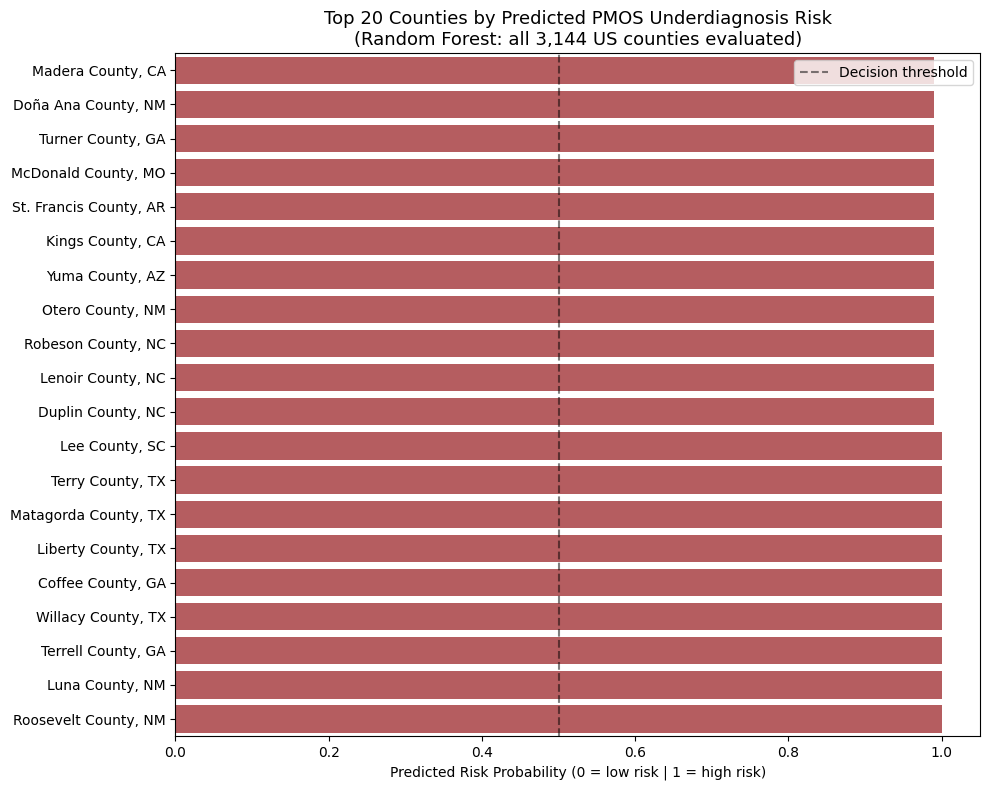

✅ SUCCESS: Full predicitons saved as pmos_predictions_all_counties.csv
Use saved file as input for Streamlit Deployment


In [21]:
# PRIMARY OUTPUT: TOP 20 HIGHEST-RISK COUNTIES FOR POLICY INTERVENTIONS
# Uses probability score for ranking (not binary label)
# Highlights counties public health resources and interventions should target first
# Saved CSV serves as input file for Streamlit Web App deployment

all_probs = rf.predict_proba(X)[:,1]
output_df = df[["FIPS", "COUNTY", "ST_ABBR"]].copy()
output_df["RISK_PROBABILITY"] = all_probs
output_df["PREDICTED_RISK"] = rf.predict(X)
output_df["TRUE_LABEL"] = y.values
output_df["label"] = output_df["COUNTY"] + ", " + output_df["ST_ABBR"]

top20 = output_df.nlargest(20, "RISK_PROBABILITY")

fig, ax = plt.subplots(figsize=(10, 8))
sns.barplot(
    data=top20.sort_values("RISK_PROBABILITY"),
    y="label", x="RISK_PROBABILITY",
    color="#c44e52", ax=ax
)

ax.set_title("Top 20 Counties by Predicted PMOS Underdiagnosis Risk\n"
"(Random Forest: all 3,144 US counties evaluated)", fontsize=13)
ax.set_xlabel("Predicted Risk Probability (0 = low risk | 1 = high risk)")
ax.set_ylabel("")
ax.axvline(0.5, color="black", linestyle="--", alpha=0.5,
           label="Decision threshold")
ax.legend()
plt.tight_layout()
plt.savefig(f"{DATASET_PATH}/top20_risk_counties.png", dpi=150)
plt.show()

# Save as CSV file for Streamlit deployment file
output_df.to_csv(f"{DATASET_PATH}/pmos_predictions_all_counties.csv",
                 index=False)
print("✅ SUCCESS: Full predicitons saved as pmos_predictions_all_counties.csv")
print("Use saved file as input for Streamlit Deployment")

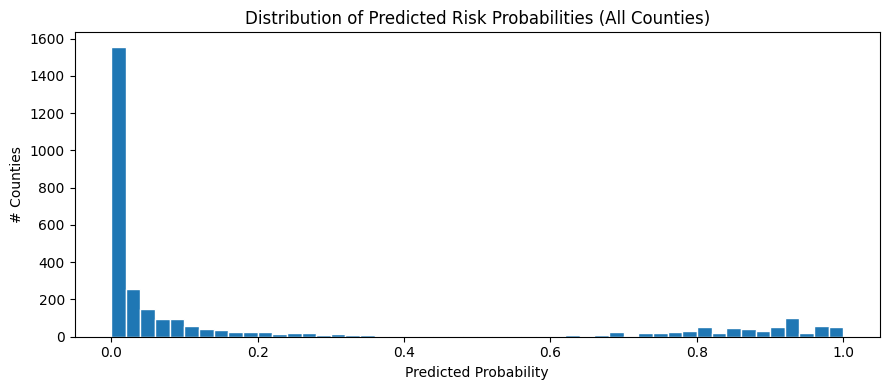

Counties with probability = 1.0: 9
Counties with probability > 0.5: 656

Top 20 counties — true label check:
                 label  RISK_PROBABILITY  TRUE_LABEL
     Coffee County, GA              1.00           1
    Terrell County, GA              1.00           1
       Luna County, NM              1.00           1
  Roosevelt County, NM              1.00           1
        Lee County, SC              1.00           1
    Liberty County, TX              1.00           1
  Matagorda County, TX              1.00           1
      Terry County, TX              1.00           1
    Willacy County, TX              1.00           1
       Yuma County, AZ              0.99           1
St. Francis County, AR              0.99           1
      Kings County, CA              0.99           1
     Madera County, CA              0.99           1
     Turner County, GA              0.99           1
   McDonald County, MO              0.99           1
   Doña Ana County, NM              0.99   

In [23]:
# VALIDATING RISK PREDICTION PROBABILITY
# All top 20 counties show probability = 1.0 (every RF tree voted high-risk)
# Validate: are these true positives, and do their feature values justify certainty?

# 1. Probability distribution across all 3,144 counties
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(output_df["RISK_PROBABILITY"], bins=50, edgecolor="white")
ax.set_title("Distribution of Predicted Risk Probabilities (All Counties)", fontsize=12)
ax.set_xlabel("Predicted Probability")
ax.set_ylabel("# Counties")
plt.tight_layout()
plt.show()

n_certain = (output_df["RISK_PROBABILITY"] == 1.0).sum()
print(f"Counties with probability = 1.0: {n_certain}")
print(f"Counties with probability > 0.5: {(output_df['RISK_PROBABILITY'] > 0.5).sum()}")

# 2. Confirm top 20 are all true positives
print("\nTop 20 counties — true label check:")
print(top20[["label", "RISK_PROBABILITY", "TRUE_LABEL"]].to_string(index=False))

In [25]:
# VISUALIZING RESULTS
# ideas: top 20 counties by predicted PMOS underdiag risk
# using predicted probability
# confusion matrices?
# decision trees -> if/then results summary for non-tech audience

In [24]:
# Visualization: County-Level Choropleth Map
from urllib.request import urlopen
import json

with urlopen("https://raw.githubusercontent.com/plotly/datasets/master/geojson-counties-fips.json") as r:
    counties_geojson = json.load(r)

predictions_csv = pd.read_csv(f"{DATASET_PATH}/pmos_predictions_all_counties.csv",
                               dtype={"FIPS": str})

fig = px.choropleth(
    predictions_csv,
    geojson=counties_geojson,
    locations="FIPS",
    color="RISK_PROBABILITY",
    color_continuous_scale="Reds",
    range_color=(0, 1),
    scope="usa",
    hover_name="label",
    hover_data={"RISK_PROBABILITY": ":.2f", "FIPS": False},
    title="Predicted PMOS Underdiagnosis Risk by US County (Random Forest)",
    labels={"RISK_PROBABILITY": "Risk Probability"}
)
fig.update_layout(
    coloraxis_colorbar=dict(title="Risk Probability<br>(0=Low | 1=High)"),
    geo_bgcolor="rgba(0,0,0,0)",
    paper_bgcolor="rgba(0,0,0,0)"
)
fig.show()

Output hidden; open in https://colab.research.google.com to view.

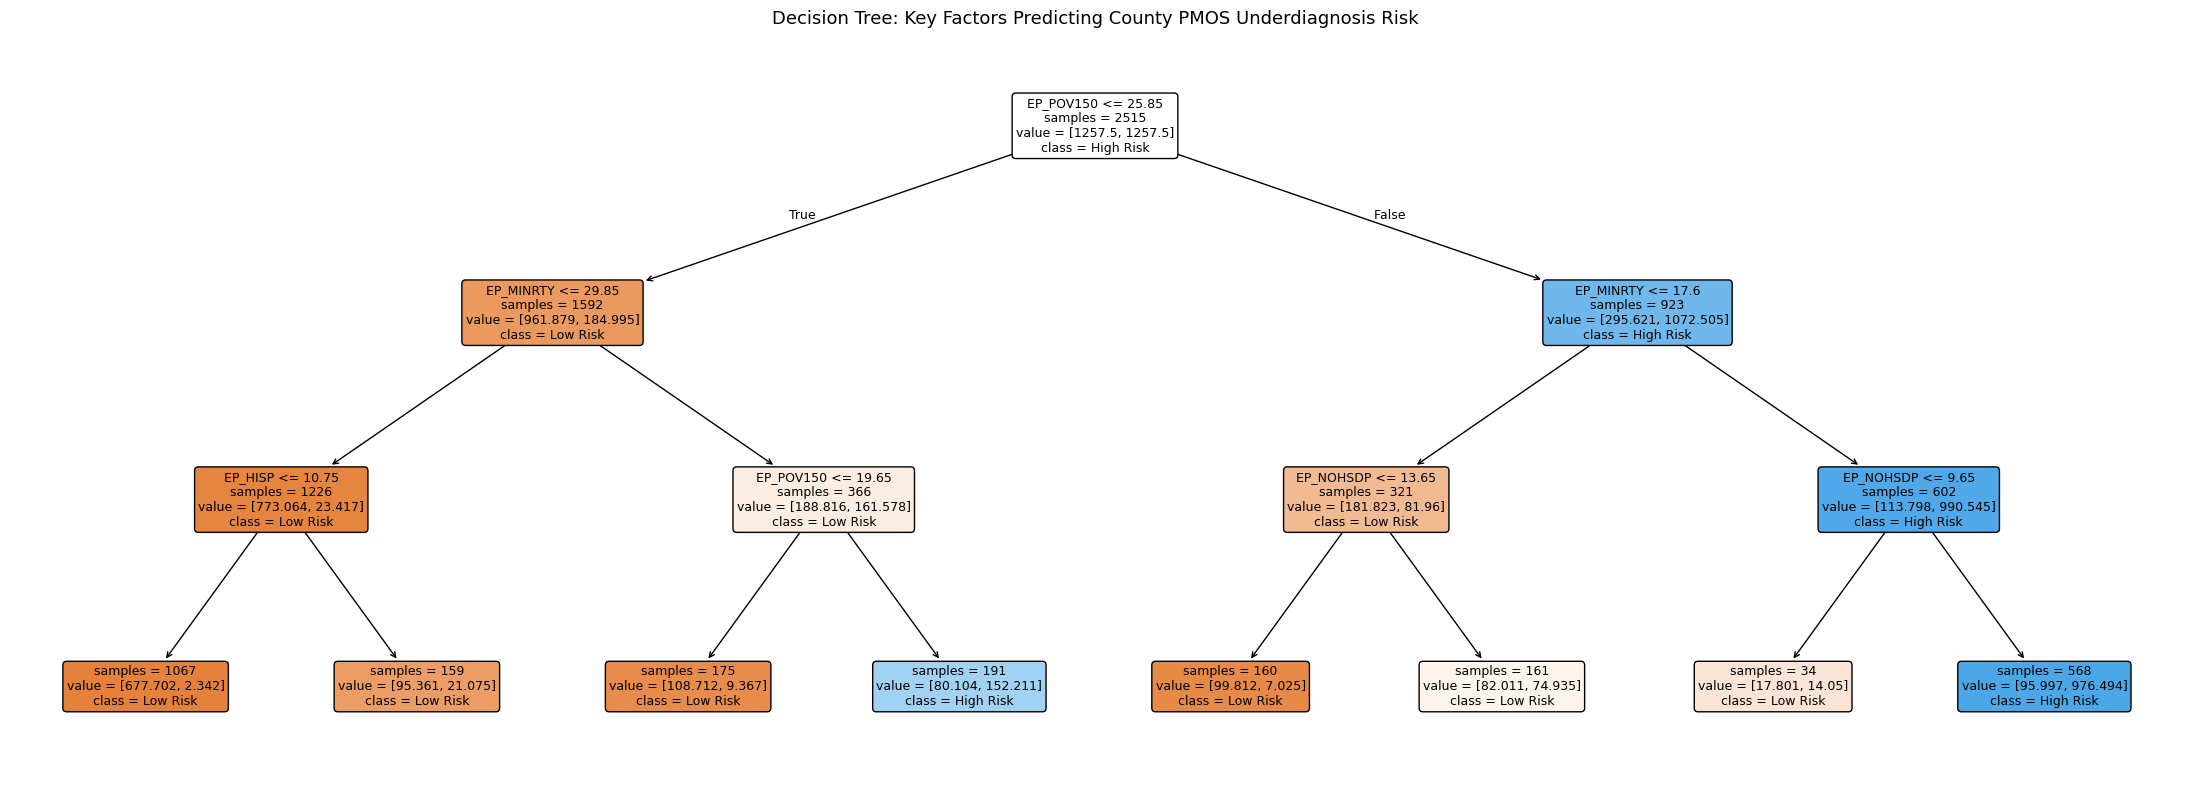

|--- EP_POV150 <= 25.85
|   |--- EP_MINRTY <= 29.85
|   |   |--- EP_HISP <= 10.75
|   |   |   |--- class: 0
|   |   |--- EP_HISP >  10.75
|   |   |   |--- class: 0
|   |--- EP_MINRTY >  29.85
|   |   |--- EP_POV150 <= 19.65
|   |   |   |--- class: 0
|   |   |--- EP_POV150 >  19.65
|   |   |   |--- class: 1
|--- EP_POV150 >  25.85
|   |--- EP_MINRTY <= 17.60
|   |   |--- EP_NOHSDP <= 13.65
|   |   |   |--- class: 0
|   |   |--- EP_NOHSDP >  13.65
|   |   |   |--- class: 0
|   |--- EP_MINRTY >  17.60
|   |   |--- EP_NOHSDP <= 9.65
|   |   |   |--- class: 0
|   |   |--- EP_NOHSDP >  9.65
|   |   |   |--- class: 1



In [26]:
# VISUALIZATION: DECISION TREE - IF/THEN SUMMARY FOR NON-TECHNICAL AUDIENCE
# Shallow tree (depth 3) trained for interpretability, not prediction
# Naturally selects most discriminative features at each split

dt = DecisionTreeClassifier(max_depth=3, class_weight="balanced", random_state=42)
dt.fit(X_train, y_train)

fig, ax = plt.subplots(figsize=(22, 8))
plot_tree(
    dt,
    feature_names=X.columns.tolist(),
    class_names=["Low Risk", "High Risk"],
    filled=True,
    rounded=True,
    fontsize=9,
    ax=ax,
    impurity=False,   # hide Gini — cleaner for non-technical audience
    proportion=False
)
ax.set_title(
    "Decision Tree: Key Factors Predicting County PMOS Underdiagnosis Risk",
    fontsize=13
)
plt.tight_layout()
plt.show()

# Print as text if/then rules for reference
rules = export_text(dt, feature_names=X.columns.tolist())
print(rules)

In [27]:
# SAVE FINAL LABELED DATASET

# Save as CSV file for Streamlit deployment file
output_df.to_csv(f"{DATASET_PATH}/pmos_predictions_all_counties.csv",
                 index=False)
print("✅ SUCCESS: Full predicitons saved as pmos_predictions_all_counties.csv")
print("Use saved file as input for Streamlit Deployment")

✅ SUCCESS: Full predicitons saved as pmos_predictions_all_counties.csv
Use saved file as input for Streamlit Deployment


In [28]:
# DEPLOYMENT

Model was deployed to Streamlit: https://14b-pmos-underdiagnosis.streamlit.app/